<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">TFM · Desarrollo modelos predictivos en el ámbito bancario</p>
<p style="margin: 0; text-align:right;">2025 - Máster universitario en Ciencias de datos</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Almudena Caballero Manzanas</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

## Índice
    1. Importación librerías
    2. Visión general y limpieza del dataset original
    3. Generación datos sintéticos
        3.1 Gaussian
            3.1.1 Generación dataset
            3.1.2 Comparación dataset sintético vs dataset original
            3.1.3 Modelo Random Forest sobre dataset original y sintético 
            3.1.4 Modelo Light Gradient Boosting sobre dataset original y sintético 
        3.2 CTGAN
            3.2.1 Generación dataset
            3.2.2 Comparación dataset sintético vs dataset original
            3.2.3 Modelo Random Forest sobre dataset original y sintético 
            3.2.4 Modelo Light Gradient Boosting sobre dataset original y sintético 
            3.2.5 Generación dataset a partir de submuestra
    4. Comparación modelo Light Gradient Boosting sobre dataset original y sintético CTGAN
    
            

### 1. Importación librerías

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sdv
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import imblearn
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from ctgan import CTGAN
import warnings
warnings.filterwarnings("ignore")
import shap

### 2. Visión general y limpieza del dataset original

In [2]:
#Carga dataset: 
ds_ori = pd.read_csv("CreditCardData.csv")
ds_ori.head(5)

,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [3]:
#Eliminar valores vacíos
ds_ori.isnull().sum()

ds_ori = ds_ori.dropna()
ds_ori.isnull().sum()

Transaction ID            0
Date                      0
Day of Week               0
Time                      0
Type of Card              0
Entry Mode                0
Amount                    0
Type of Transaction       0
Merchant Group            0
Country of Transaction    0
Shipping Address          0
Country of Residence      0
Gender                    0
Age                       0
Bank                      0
Fraud                     0
dtype: int64

In [4]:
#Analizar tipo de datos
ds_ori.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99977 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Transaction ID          99977 non-null  object 
 1   Date                    99977 non-null  object 
 2   Day of Week             99977 non-null  object 
 3   Time                    99977 non-null  int64  
 4   Type of Card            99977 non-null  object 
 5   Entry Mode              99977 non-null  object 
 6   Amount                  99977 non-null  object 
 7   Type of Transaction     99977 non-null  object 
 8   Merchant Group          99977 non-null  object 
 9   Country of Transaction  99977 non-null  object 
 10  Shipping Address        99977 non-null  object 
 11  Country of Residence    99977 non-null  object 
 12  Gender                  99977 non-null  object 
 13  Age                     99977 non-null  float64
 14  Bank                    99977 non-null

In [5]:
#Modificar formatos dataset
# Columna date a fecha
ds_ori['Date'] = pd.to_datetime(ds_ori['Date'])

#Eliminar símbolo de columna Amount y conversión a tipo int
ds_ori['Amount'] = ds_ori['Amount'].replace('£', '', regex=True).astype(int)

ds_ori.head()

,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,2020-10-14,Wednesday,19,Visa,Tap,5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,2020-10-14,Wednesday,17,MasterCard,PIN,288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,2020-10-14,Wednesday,14,Visa,Tap,5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,2020-10-13,Tuesday,14,Visa,Tap,28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,2020-10-13,Tuesday,23,Visa,CVC,91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


### 3. Generación datos sintéticos

### 3.1 Gaussian

#### 3.1.1 Generación dataset

In [6]:
#Generar datos sintéticos. Preparación: no considerar la columa Transaction ID
sint_GCS = ds_ori.drop(columns=[ds_ori.columns[0]])

In [7]:
datossinteticos = SingleTableMetadata()
datossinteticos.detect_from_dataframe(sint_GCS)

In [8]:
# Especificar tipos de datos para el modelo
datossinteticos.update_column(
    column_name='Fraud',
    sdtype='categorical'
)

datossinteticos.update_column(
    column_name='Date',
    sdtype='datetime',
    datetime_format='%Y-%m-%d'
)


In [9]:
# Generar modelo
synthesizer = GaussianCopulaSynthesizer(
    metadata=datossinteticos,
    enforce_min_max_values=True,
    enforce_rounding=True
)

synthesizer.fit(sint_GCS)


In [10]:
#Generar la muestra
sint_GCS_50k = synthesizer.sample(num_rows=50000)
sint_GCS_50k.head()

,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,2020-10-13,Tuesday,13,Visa,CVC,71,POS,Children,India,United Kingdom,Russia,F,46.4,Metro,0
1,2020-10-14,Wednesday,14,MasterCard,CVC,397,POS,Services,United Kingdom,United Kingdom,United Kingdom,F,63.7,Barclays,0
2,2020-10-14,Tuesday,20,Visa,PIN,374,ATM,Food,United Kingdom,United Kingdom,United Kingdom,M,55.3,HSBC,0
3,2020-10-15,Wednesday,16,Visa,CVC,7,Online,Food,United Kingdom,USA,United Kingdom,F,39.3,Halifax,0
4,2020-10-13,Tuesday,23,MasterCard,Tap,30,POS,Fashion,United Kingdom,India,United Kingdom,M,35.2,Lloyds,0


#### 3.1.2 Comparación dataset sintético vs dataset original

In [11]:
#Comparación ratio fraude entre ambos datasets
print("Dataset Original:")
print(ds_ori['Fraud'].value_counts(normalize=True))


print("\nDataset sintético GCS con 50.000:")
print(sint_GCS_50k['Fraud'].value_counts(normalize=True))

Dataset Original:
0    0.928063
1    0.071937
Name: Fraud, dtype: float64

Dataset sintético GCS con 50.000:
0    0.9284
1    0.0716
Name: Fraud, dtype: float64


In [12]:
#Añadimos la columna ID al sintético
sint_GCS_50k.insert(
    0,
    'Transaction ID', 
    [f"Transaction ID_{i+1}" for i in range(len(sint_GCS_50k))]
)

In [13]:
sint_GCS_50k.head()

,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,Transaction ID_1,2020-10-13,Tuesday,13,Visa,CVC,71,POS,Children,India,United Kingdom,Russia,F,46.4,Metro,0
1,Transaction ID_2,2020-10-14,Wednesday,14,MasterCard,CVC,397,POS,Services,United Kingdom,United Kingdom,United Kingdom,F,63.7,Barclays,0
2,Transaction ID_3,2020-10-14,Tuesday,20,Visa,PIN,374,ATM,Food,United Kingdom,United Kingdom,United Kingdom,M,55.3,HSBC,0
3,Transaction ID_4,2020-10-15,Wednesday,16,Visa,CVC,7,Online,Food,United Kingdom,USA,United Kingdom,F,39.3,Halifax,0
4,Transaction ID_5,2020-10-13,Tuesday,23,MasterCard,Tap,30,POS,Fashion,United Kingdom,India,United Kingdom,M,35.2,Lloyds,0


In [14]:
#Comparación fraude por variables
num_cols = sint_GCS_50k.select_dtypes(include=['int64', 'float64']).columns

print("Estadísticas comparadas (numéricas):")
print("Original:")
print(ds_ori[num_cols].describe())

print("\nSintético GCS con 50.000:")
print(sint_GCS_50k[num_cols].describe())


Estadísticas comparadas (numéricas):
Original:
               Time           Age         Fraud
count  99977.000000  99977.000000  99977.000000
mean      14.563100     44.993595      0.071937
std        5.308202      9.948121      0.258384
min        0.000000     15.000000      0.000000
25%       10.000000     38.200000      0.000000
50%       15.000000     44.900000      0.000000
75%       19.000000     51.700000      0.000000
max       24.000000     86.100000      1.000000

Sintético GCS con 50.000:
               Time           Age         Fraud
count  50000.000000  50000.000000  50000.000000
mean      14.594900     44.996086      0.071600
std        5.353041     10.001810      0.257827
min        0.000000     15.000000      0.000000
25%       11.000000     38.100000      0.000000
50%       15.000000     45.000000      0.000000
75%       19.000000     51.800000      0.000000
max       24.000000     86.100000      1.000000


In [15]:
cat_cols = sint_GCS_50k.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"\nColumna: {col}")
    print("Original:")
    print(ds_ori[col].value_counts(normalize=True))
    print("Sintético GCS con 50.000:")
    print(sint_GCS_50k[col].value_counts(normalize=True))



Columna: Transaction ID
Original:
#2547 017    0.00005
#2617 708    0.00004
#2748 710    0.00003
#3603 721    0.00003
#3567 660    0.00003
              ...   
#2844 374    0.00001
#2557 633    0.00001
#3316 605    0.00001
#2889 615    0.00001
#3107 092    0.00001
Name: Transaction ID, Length: 95657, dtype: float64
Sintético GCS con 50.000:
Transaction ID_1        0.00002
Transaction ID_33351    0.00002
Transaction ID_33329    0.00002
Transaction ID_33330    0.00002
Transaction ID_33331    0.00002
                         ...   
Transaction ID_16669    0.00002
Transaction ID_16670    0.00002
Transaction ID_16671    0.00002
Transaction ID_16672    0.00002
Transaction ID_50000    0.00002
Name: Transaction ID, Length: 50000, dtype: float64

Columna: Day of Week
Original:
Wednesday    0.501775
Tuesday      0.497965
Friday       0.000140
Thursday     0.000120
Name: Day of Week, dtype: float64
Sintético GCS con 50.000:
Wednesday    0.50106
Tuesday      0.49878
Friday       0.00012
Thursday 

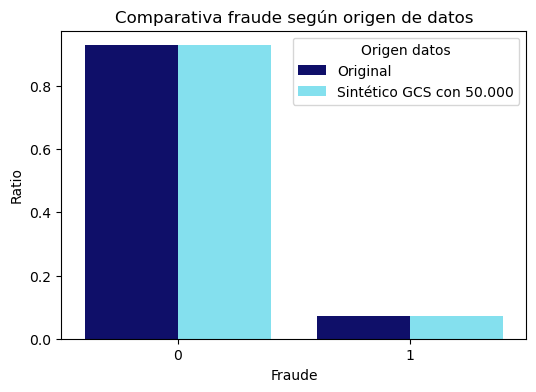

In [16]:
# Comparación visual
ori_target = ds_ori['Fraud'].value_counts(normalize=True).sort_index()
sint_target = sint_GCS_50k['Fraud'].value_counts(normalize=True).sort_index()

# Crear DataFrame para grafico
df_target = pd.DataFrame({
    'Original': ori_target,
    'Sintético GCS con 50.000': sint_target
}).reset_index().melt(id_vars='index', var_name='Origen datos', value_name='Ratio')

# Gráfico
plt.figure(figsize=(6,4))
sns.barplot(x='index', y='Ratio', hue='Origen datos', data=df_target, palette={
        'Original': '#000078',
        'Sintético GCS con 50.000': '#73EDFF'
    })
plt.title('Comparativa fraude según origen de datos')
plt.xlabel('Fraude')
plt.ylabel('Ratio')
plt.show()


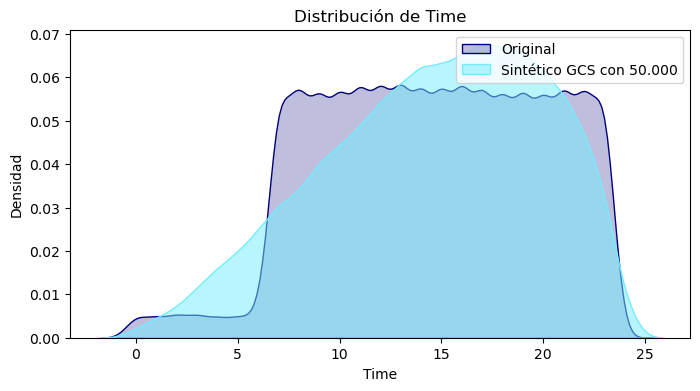

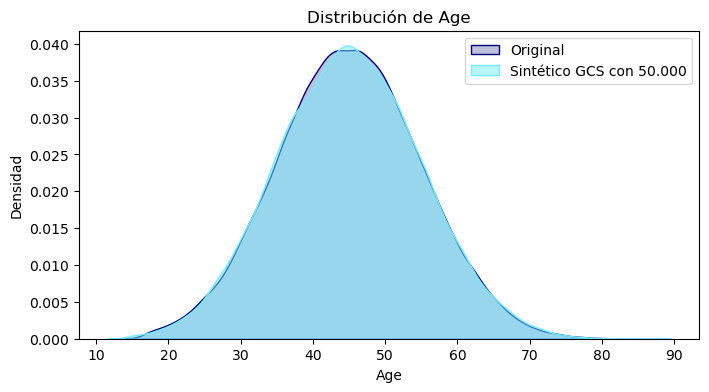

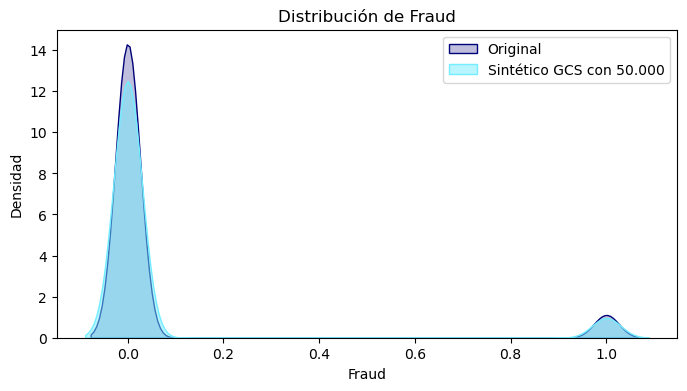

In [17]:
#Distribución visual fraude por origen de datos en variables numéricas 
num_cols = sint_GCS_50k.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(ds_ori[col], label='Original', fill=True, color='#000078')
    sns.kdeplot(sint_GCS_50k[col], label='Sintético GCS con 50.000', fill=True, alpha=0.5, color='#73EDFF')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()


#### 3.1.3 Modelo Random Forest sobre dataset original y sintético 

In [18]:
#Aplicamos modelo RandomForest
#Variables
id_col = ds_ori.columns[0]
target_col = 'Fraud'

X = ds_ori.drop(columns=[id_col, target_col])
y = ds_ori[target_col]


In [19]:
#Separación en train y test
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [20]:
#Preparación dataset original
X_train_ori = X_train_real
y_train_ori = y_train_real

X_test_ori = X_test_real
y_test_ori = y_test_real


In [21]:
#Original + Sintético GCS con 50.000
X_GCS_50k = sint_GCS_50k.drop(columns=[id_col, target_col])
y_GCS_50k = sint_GCS_50k[target_col]

X_train_GCS_50k = pd.concat([X_train_real, X_GCS_50k])
y_train_GCS_50k = pd.concat([y_train_real, y_GCS_50k])


In [22]:
#Preprocesado variables numéricas y categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [23]:
#Creación y evaluación del modelo
pipeline_ori = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])
pipeline_ori.fit(X_train_ori, y_train_ori)


pipeline_GCS_50k = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])
pipeline_GCS_50k.fit(X_train_GCS_50k, y_train_GCS_50k)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Time', 'Age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Day of Week', 'Type of Card', 'Entry Mode', 'Type of Transaction',
       'Merchant Group', 'Country of Transaction', 'Shipping Address',
       'Country of Residence', 'Gender', 'Bank'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [24]:
#Comparación resultados
y_pred_ori = pipeline_ori.predict(X_test_ori)
y_proba_ori = pipeline_ori.predict_proba(X_test_ori)[:, 1]

auc_ori = roc_auc_score(y_test_ori, y_proba_ori)
recall_ori = recall_score(y_test_ori, y_pred_ori)
f1_ori = f1_score(y_test_ori, y_pred_ori)

y_pred_GCS_50k = pipeline_GCS_50k.predict(X_test_ori)
y_proba_GCS_50k = pipeline_GCS_50k.predict_proba(X_test_ori)[:, 1]

auc_GCS_50k = roc_auc_score(y_test_ori, y_proba_GCS_50k)
recall_GCS_50k = recall_score(y_test_ori, y_pred_GCS_50k)
f1_GCS_50k = f1_score(y_test_ori, y_pred_GCS_50k)

print("Random Forest - Dataset Original")
print(f"AUC:      {auc_ori:.4f}")
print(f"Recall:   {recall_ori:.4f}")
print(f"F1-score: {f1_ori:.4f}")

print("\nRandom Forest - Dataset Gaussian 50k")
print(f"AUC:      {auc_GCS_50k:.4f}")
print(f"Recall:   {recall_GCS_50k:.4f}")
print(f"F1-score: {f1_GCS_50k:.4f}")


Random Forest - Dataset Original
AUC:      0.9889
Recall:   0.7337
F1-score: 0.8011

Random Forest - Dataset Gaussian 50k
AUC:      0.9824
Recall:   0.6690
F1-score: 0.7647


In [25]:
#Prueba generando solo 25.000 nuevos datos
sint_GCS_25k = synthesizer.sample(num_rows=25000)
sint_GCS_25k.insert(
    0,
    'Transaction ID', 
    [f"Transaction ID_{i+1}" for i in range(len(sint_GCS_25k))]
)

#Original + Sintético GCS con 25.000
X_GCS_25k = sint_GCS_25k.drop(columns=[id_col, target_col])
y_GCS_25k = sint_GCS_25k[target_col]

X_train_GCS_25k = pd.concat([X_train_real, X_GCS_25k])
y_train_GCS_25k = pd.concat([y_train_real, y_GCS_25k])

#Evaluación
pipeline_GCS_25k = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])
pipeline_GCS_25k.fit(X_train_GCS_25k, y_train_GCS_25k)

#Resultados
y_pred_GCS_25k = pipeline_GCS_25k.predict(X_test_ori)
y_proba_GCS_25k = pipeline_GCS_25k.predict_proba(X_test_ori)[:, 1]

auc_GCS_25k = roc_auc_score(y_test_ori, y_proba_GCS_25k)
recall_GCS_25k = recall_score(y_test_ori, y_pred_GCS_25k)
f1_GCS_25k = f1_score(y_test_ori, y_pred_GCS_25k)


In [26]:
#Comparación de los tres resultados
print("Random Forest - Dataset Original")
print(f"AUC:      {auc_ori:.4f}")
print(f"Recall:   {recall_ori:.4f}")
print(f"F1-score: {f1_ori:.4f}")

print("\nRandom Forest - Dataset Gaussian 50k")
print(f"AUC:      {auc_GCS_50k:.4f}")
print(f"Recall:   {recall_GCS_50k:.4f}")
print(f"F1-score: {f1_GCS_50k:.4f}")

print("\nRandom Forest - Dataset Gaussian 25k")
print(f"AUC:      {auc_GCS_25k:.4f}")
print(f"Recall:   {recall_GCS_25k:.4f}")
print(f"F1-score: {f1_GCS_25k:.4f}")


Random Forest - Dataset Original
AUC:      0.9889
Recall:   0.7337
F1-score: 0.8011

Random Forest - Dataset Gaussian 50k
AUC:      0.9824
Recall:   0.6690
F1-score: 0.7647

Random Forest - Dataset Gaussian 25k
AUC:      0.9849
Recall:   0.7065
F1-score: 0.7888


In [27]:
#Aplicación SMOTE sobre el original + sintético de 25k
smote = SMOTE(
    sampling_strategy=0.3,  
    random_state=42
)

pipeline_rf_smote = ImbPipeline([
    ('prep', preprocessor), 
    ('smote', smote),        
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])
pipeline_rf_smote.fit(X_train_GCS_25k, y_train_GCS_25k)

y_pred_smote = pipeline_rf_smote.predict(X_test_ori)
y_proba_smote = pipeline_rf_smote.predict_proba(X_test_ori)[:, 1]

auc_GCS_smote = roc_auc_score(y_test_ori, y_proba_smote)
recall_GCS_smote = recall_score(y_test_ori, y_pred_smote)
f1_GCS_smote = f1_score(y_test_ori, y_pred_smote)


In [28]:
#Comparación de resultados
print("Random Forest - Dataset Original")
print(f"AUC:      {auc_ori:.4f}")
print(f"Recall:   {recall_ori:.4f}")
print(f"F1-score: {f1_ori:.4f}")

print("\nRandom Forest - Dataset Gaussian 50k")
print(f"AUC:      {auc_GCS_50k:.4f}")
print(f"Recall:   {recall_GCS_50k:.4f}")
print(f"F1-score: {f1_GCS_50k:.4f}")

print("\nRandom Forest - Dataset Gaussian 25k")
print(f"AUC:      {auc_GCS_25k:.4f}")
print(f"Recall:   {recall_GCS_25k:.4f}")
print(f"F1-score: {f1_GCS_25k:.4f}")

print("\nRandom Forest - Dataset Gaussian 25k - SMOTE")
print(f"AUC:      {auc_GCS_smote:.4f}")
print(f"Recall:   {recall_GCS_smote:.4f}")
print(f"F1-score: {f1_GCS_smote:.4f}")


Random Forest - Dataset Original
AUC:      0.9889
Recall:   0.7337
F1-score: 0.8011

Random Forest - Dataset Gaussian 50k
AUC:      0.9824
Recall:   0.6690
F1-score: 0.7647

Random Forest - Dataset Gaussian 25k
AUC:      0.9849
Recall:   0.7065
F1-score: 0.7888

Random Forest - Dataset Gaussian 25k - SMOTE
AUC:      0.9847
Recall:   0.7448
F1-score: 0.7984


#### 3.1.4 Modelo Light Gradient Boosting sobre dataset original y sintético 

In [29]:
#Creación y evaluación del modelo
pipeline_lgbm_ori = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
])
pipeline_lgbm_ori.fit(X_train_ori, y_train_ori)

pipeline_lgbm_GCS_50k = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
])
pipeline_lgbm_GCS_50k.fit(X_train_GCS_50k, y_train_GCS_50k)


[LightGBM] [Info] Number of positive: 5754, number of negative: 74227
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.195478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 79981, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 9334, number of negative: 120647
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of t

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Time', 'Age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Day of Week', 'Type of Card', 'Entry Mode', 'Type of Transaction',
       'Merchant Group', 'Country of Transaction', 'Shipping Address',
       'Country of Residence', 'Gender', 'Bank'],
      dtype='object'))])),
                ('model',
                 LGBMClassifier(class_weight='balanced', learning_rate=0.05,
                                max_depth=6, n_estimators=500,
                                random_state=42))])

In [30]:
#Comparación resultados
y_pred_lgbm_ori = pipeline_lgbm_ori.predict(X_test_ori)
y_proba_lgbm_ori = pipeline_lgbm_ori.predict_proba(X_test_ori)[:, 1]

auc_lgbm_ori = roc_auc_score(y_test_ori, y_proba_lgbm_ori)
recall_lgbm_ori = recall_score(y_test_ori, y_pred_lgbm_ori)
f1_lgbm_ori = f1_score(y_test_ori, y_pred_lgbm_ori)

y_pred_lgbm_GCS_50k = pipeline_lgbm_GCS_50k.predict(X_test_ori)
y_proba_lgbm_GCS_50k = pipeline_lgbm_GCS_50k.predict_proba(X_test_ori)[:, 1]

auc_lgbm_GCS_50k = roc_auc_score(y_test_ori, y_proba_lgbm_GCS_50k)
recall_lgbm_GCS_50k = recall_score(y_test_ori, y_pred_lgbm_GCS_50k)
f1_lgbm_GCS_50k = f1_score(y_test_ori, y_pred_lgbm_GCS_50k)

print("Random Forest - Dataset Original")
print(f"AUC:      {auc_ori:.4f}")
print(f"Recall:   {recall_ori:.4f}")
print(f"F1-score: {f1_ori:.4f}")

print("\nLight Gradient Boosting - Dataset Original")
print(f"AUC:      {auc_lgbm_ori:.4f}")
print(f"Recall:   {recall_lgbm_ori:.4f}")
print(f"F1-score: {f1_lgbm_ori:.4f}")

print("\nLight Gradient Boosting - Dataset Gaussian 50k")
print(f"AUC:      {auc_lgbm_GCS_50k:.4f}")
print(f"Recall:   {recall_lgbm_GCS_50k:.4f}")
print(f"F1-score: {f1_lgbm_GCS_50k:.4f}")

Random Forest - Dataset Original
AUC:      0.9889
Recall:   0.7337
F1-score: 0.8011

Light Gradient Boosting - Dataset Original
AUC:      0.9898
Recall:   0.9270
F1-score: 0.7266

Light Gradient Boosting - Dataset Gaussian 50k
AUC:      0.9888
Recall:   0.9624
F1-score: 0.6660


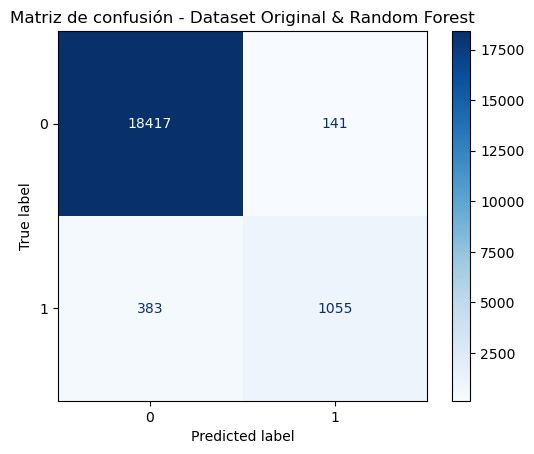

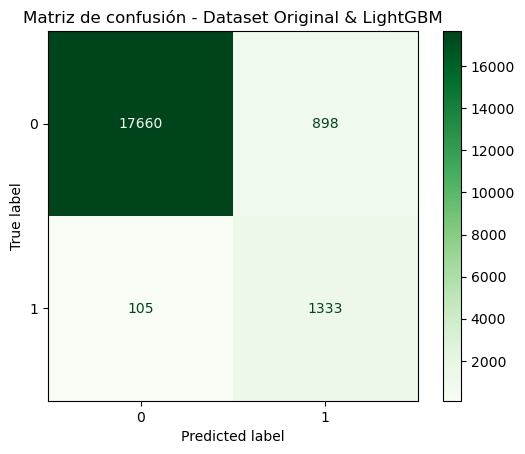

In [59]:
#Matrices de confusion dataset original

cm_ori_lgbm = confusion_matrix(y_test_ori, y_pred_lgbm_ori)
disp_ori_lgbm = ConfusionMatrixDisplay(confusion_matrix=cm_ori_lgbm, display_labels=[0, 1])

cm_ori_rf = confusion_matrix(y_test_ori, y_pred_ori)
disp_ori_rf = ConfusionMatrixDisplay(confusion_matrix=cm_ori_rf, display_labels=[0, 1])

disp_ori_rf.plot(cmap='Blues', values_format='d')
plt.title("Matriz de confusión - Dataset Original & Random Forest")
plt.show()

disp_ori_lgbm.plot(cmap='Greens', values_format='d')
plt.title("Matriz de confusión - Dataset Original & LightGBM")
plt.show()

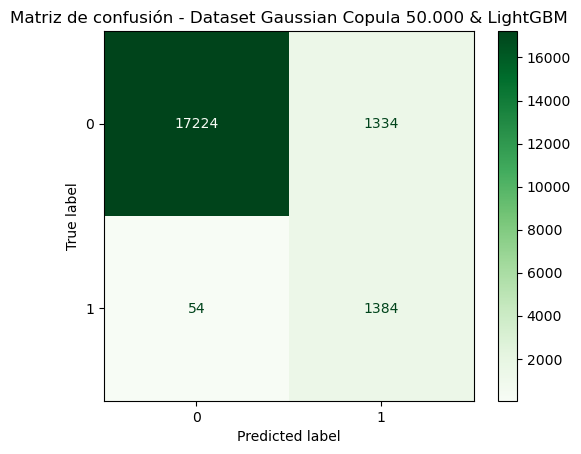

In [61]:
#Matriz confusion GC50K

cm_GCS_50k = confusion_matrix(y_test_ori, y_pred_lgbm_GCS_50k)
disp_GCS_50k_lgbm = ConfusionMatrixDisplay(confusion_matrix=cm_GCS_50k, display_labels=[0, 1])

disp_GCS_50k_lgbm.plot(cmap='Greens', values_format='d')
plt.title("Matriz de confusión - Dataset Gaussian Copula 50.000 & LightGBM")
plt.show()

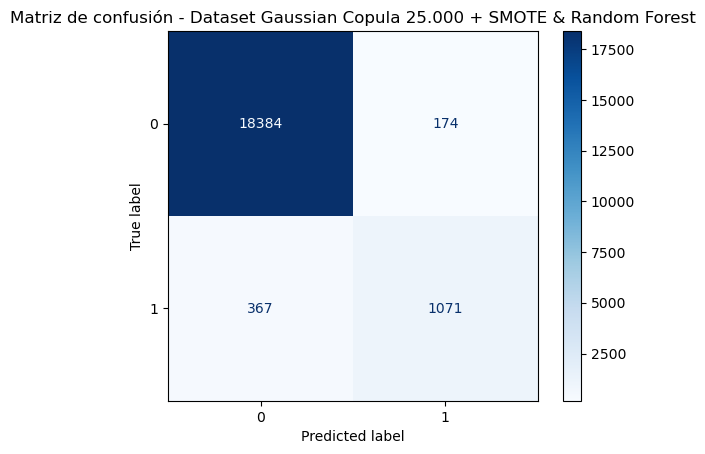

In [62]:
#Matriz confusion GC25K + SMOTE

cm_GCS_25k_sm = confusion_matrix(y_test_ori, y_pred_smote)
disp_GCS_25k_sm_rf = ConfusionMatrixDisplay(confusion_matrix=cm_GCS_25k_sm, display_labels=[0, 1])

disp_GCS_25k_sm_rf.plot(cmap='Blues', values_format='d')
plt.title("Matriz de confusión - Dataset Gaussian Copula 25.000 + SMOTE & Random Forest")
plt.show()

### 3.2 CTGAN

#### 3.2.1 Generación dataset

In [31]:
sint_GAN = ds_ori.drop(columns=[ds_ori.columns[0]])
sint_GAN.head()


,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,2020-10-14,Wednesday,19,Visa,Tap,5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,2020-10-14,Wednesday,17,MasterCard,PIN,288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,2020-10-14,Wednesday,14,Visa,Tap,5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,2020-10-13,Tuesday,14,Visa,Tap,28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,2020-10-13,Tuesday,23,Visa,CVC,91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [32]:
#Eliminar columna fecha para evitar problemas en la generación de los datos
sint_GAN = sint_GAN.drop(columns=[sint_GAN.columns[0]])
sint_GAN.head()

,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,Wednesday,19,Visa,Tap,5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,Wednesday,17,MasterCard,PIN,288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,Wednesday,14,Visa,Tap,5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,Tuesday,14,Visa,Tap,28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,Tuesday,23,Visa,CVC,91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [33]:
#Variables categóricas
categorical_cols = sint_GAN.select_dtypes(
    include=['object', 'category']
).columns.tolist()

if 'Fraud' not in categorical_cols:
    categorical_cols.append('Fraud')
    
categorical_cols

['Day of Week',
 'Type of Card',
 'Entry Mode',
 'Type of Transaction',
 'Merchant Group',
 'Country of Transaction',
 'Shipping Address',
 'Country of Residence',
 'Gender',
 'Bank',
 'Fraud']

In [34]:
#Generar GAN con 50epochs. Tiempo: 30mins. Provoca más fraude pero no ajusta mal las variables
ctgan_50 = CTGAN(
    epochs=50,
    batch_size=5000,
    verbose=True
)

ctgan_50.fit(sint_GAN, categorical_cols)


Gen. (-0.63) | Discrim. (-0.24): 100%|██████████| 50/50 [55:16<00:00, 66.33s/it] 


In [35]:
#Generar datos y comparar con el original
sint_GAN_50_50k = ctgan_50.sample(50000)

print("Dataset Original:")
print(ds_ori['Fraud'].value_counts(normalize=True))

print("\nDataset sintético GAN con 50.000 y 50 epochs:")
print(sint_GAN_50_50k['Fraud'].value_counts(normalize=True))


Dataset Original:
0    0.928063
1    0.071937
Name: Fraud, dtype: float64

Dataset sintético GAN con 50.000 y 50 epochs:
0    0.91402
1    0.08598
Name: Fraud, dtype: float64



#### 3.2.2 Comparación dataset sintético vs dataset original

In [36]:
#Generar datos y comparar con el original

print("Dataset Original:")
print(ds_ori['Fraud'].value_counts(normalize=True))

print("\nDataset sintético GAN con 50.000 y 50 epochs:")
print(sint_GAN_50_50k['Fraud'].value_counts(normalize=True))


Dataset Original:
0    0.928063
1    0.071937
Name: Fraud, dtype: float64

Dataset sintético GAN con 50.000 y 50 epochs:
0    0.91402
1    0.08598
Name: Fraud, dtype: float64


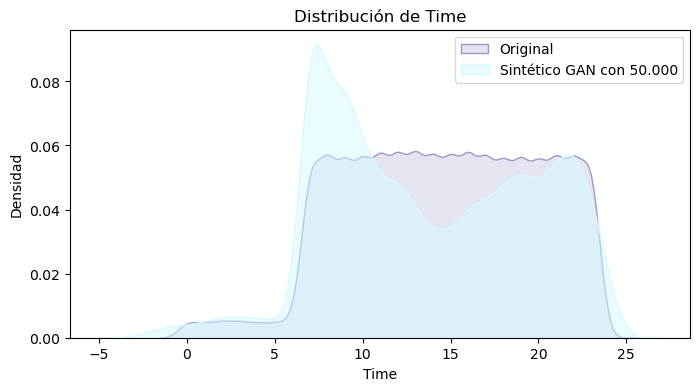

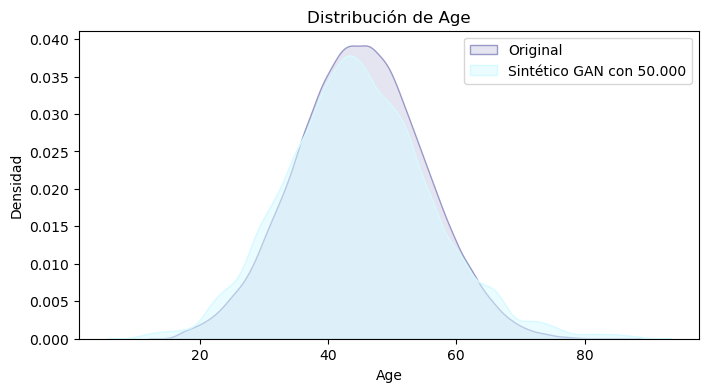

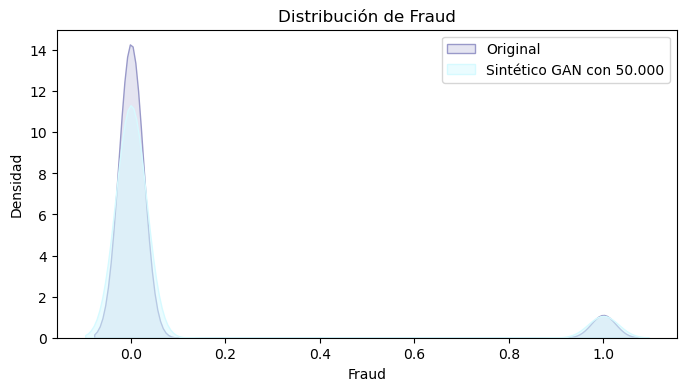

In [37]:
num_cols = sint_GAN_50_50k.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(sint_GAN[col], label='Original', fill=True, color='#9999C9')
    sns.kdeplot(sint_GAN_50_50k[col], label='Sintético GAN con 50.000', fill=True, alpha=0.5, color='#D6FAFF')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

#### 3.2.3 Modelo Random Forest sobre dataset original y sintético 

In [38]:
#Aplicamos modelo RandomForest con dataset total
#Preparación del original sin fecha
X_train_ori = X_train_real.drop(columns=['Date'])
y_train_ori = y_train_real.drop(columns=['Date'])

X_test_ori = X_test_real.drop(columns=['Date'])
y_test_ori = y_test_real.drop(columns=['Date'])


#Original + Sintético GAN con 50.000 y 50 epochs
X_GAN = sint_GAN_50_50k.drop(columns=['Fraud'])
y_GAN = sint_GAN_50_50k['Fraud']

X_train_GAN = pd.concat([X_train_ori, X_GAN])
y_train_GAN = pd.concat([y_train_ori, y_GAN])

In [39]:
#Preprocesado variables numéricas y categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [40]:
#Creación y evaluación del modelo

pipeline_GAN_50k = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])
pipeline_GAN_50k.fit(X_train_GAN, y_train_GAN)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Time', 'Age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Day of Week', 'Type of Card', 'Entry Mode', 'Type of Transaction',
       'Merchant Group', 'Country of Transaction', 'Shipping Address',
       'Country of Residence', 'Gender', 'Bank'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [41]:
#Resultados
y_pred_GAN = pipeline_GAN_50k.predict(X_test_ori)
y_proba_GAN = pipeline_GAN_50k.predict_proba(X_test_ori)[:, 1]

auc_GAN = roc_auc_score(y_test_ori, y_proba_GAN)
recall_GAN = recall_score(y_test_ori, y_pred_GAN)
f1_GAN = f1_score(y_test_ori, y_pred_GAN)

print("Random Forest - Dataset Original")
print(f"AUC:      {auc_ori:.4f}")
print(f"Recall:   {recall_ori:.4f}")
print(f"F1-score: {f1_ori:.4f}")

print("\nRandom Forest - Dataset GAN 50k")
print(f"AUC:      {auc_GAN:.4f}")
print(f"Recall:   {recall_GAN:.4f}")
print(f"F1-score: {f1_GAN:.4f}")

Random Forest - Dataset Original
AUC:      0.9889
Recall:   0.7337
F1-score: 0.8011

Random Forest - Dataset GAN 50k
AUC:      0.9771
Recall:   0.6711
F1-score: 0.7653


#### 3.2.4 Modelo Light Gradient Boosting sobre dataset original y sintético 

In [42]:
#Creación y evaluación del modelo
pipeline_lgbm_GAN_50k = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
])
pipeline_lgbm_GAN_50k.fit(X_train_GAN, y_train_GAN)

[LightGBM] [Info] Number of positive: 10053, number of negative: 119928
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.131718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 379
[LightGBM] [Info] Number of data points in the train set: 129981, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Time', 'Age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Day of Week', 'Type of Card', 'Entry Mode', 'Type of Transaction',
       'Merchant Group', 'Country of Transaction', 'Shipping Address',
       'Country of Residence', 'Gender', 'Bank'],
      dtype='object'))])),
                ('model',
                 LGBMClassifier(class_weight='balanced', learning_rate=0.05,
                                max_depth=6, n_estimators=500,
                                random_state=42))])

In [43]:
#Comparación resultados
y_pred_lgbm_GAN_50k = pipeline_lgbm_GAN_50k.predict(X_test_ori)
y_proba_lgbm_GAN_50k = pipeline_lgbm_GAN_50k.predict_proba(X_test_ori)[:, 1]

auc_lgbm_GAN_50k = roc_auc_score(y_test_ori, y_proba_lgbm_GAN_50k)
recall_lgbm_GAN_50k = recall_score(y_test_ori, y_pred_lgbm_GAN_50k)
f1_lgbm_GAN_50k = f1_score(y_test_ori, y_pred_lgbm_GAN_50k)

print("\nGradient Boosting - Dataset Original")
print(f"AUC:      {auc_lgbm_ori:.4f}")
print(f"Recall:   {recall_lgbm_ori:.4f}")
print(f"F1-score: {f1_lgbm_ori:.4f}")

print("\nGradient Boosting - Dataset GAN 50k")
print(f"AUC:      {auc_lgbm_GAN_50k:.4f}")
print(f"Recall:   {recall_lgbm_GAN_50k:.4f}")
print(f"F1-score: {f1_lgbm_GAN_50k:.4f}")



Gradient Boosting - Dataset Original
AUC:      0.9898
Recall:   0.9270
F1-score: 0.7266

Gradient Boosting - Dataset GAN 50k
AUC:      0.9835
Recall:   0.9402
F1-score: 0.6182


#### 3.2.5 Generación dataset a partir de submuestra

In [44]:
#Tomar una submuestra del dataset original para hacer el sintético sin penalizar tiempos y mejor ajuste
pct = 0.25
sint_GAN_sub = sint_GAN.groupby(target_col, group_keys=False).apply(
    lambda x: x.sample(frac=pct, random_state=42)
)

print("Submuestra Dataset Original:")
print(sint_GAN_sub['Fraud'].value_counts(normalize=True))


Submuestra Dataset Original:
0    0.928063
1    0.071937
Name: Fraud, dtype: float64


In [45]:
sint_GAN_sub.describe()

,Time,Amount,Age,Fraud
count,24994.000000,24994.000000,24994.000000,24994.000000
mean,14.568897,112.021885,44.996283,0.071937
std,5.326441,123.356276,9.966022,0.258389
min,0.000000,5.000000,16.000000,0.000000
25%,10.000000,17.000000,38.200000,0.000000
50%,15.000000,29.000000,44.900000,0.000000
75%,19.000000,206.750000,51.700000,0.000000
max,23.000000,400.000000,82.900000,1.000000


In [46]:
sint_GAN_sub.head()

,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
48506,Tuesday,10,Visa,PIN,171,ATM,Subscription,United Kingdom,United Kingdom,United Kingdom,F,30.7,Monzo,0
20951,Wednesday,10,Visa,PIN,28,ATM,Services,United Kingdom,United Kingdom,United Kingdom,F,31.9,Halifax,0
77143,Tuesday,23,MasterCard,CVC,28,Online,Services,United Kingdom,United Kingdom,United Kingdom,M,52.1,Metro,0
4788,Wednesday,20,MasterCard,CVC,309,Online,Electronics,United Kingdom,Russia,United Kingdom,M,38.7,Metro,0
50032,Tuesday,19,MasterCard,CVC,12,Online,Services,USA,USA,USA,F,35.8,Metro,0


In [47]:
#Generar GAN con 150 epochs y menor batch para mejor aprendizaje
ctgan_sub = CTGAN(
    epochs=150,         
    batch_size=1500,    
    verbose=True      
)

ctgan_sub.fit(sint_GAN_sub, categorical_cols)

Gen. (-0.83) | Discrim. (-0.27): 100%|██████████| 150/150 [44:19<00:00, 17.73s/it]


In [48]:
#Generar datos y comparar con el original
sint_GAN_sub_8k = ctgan_sub.sample(8000)

print("Submuestra Dataset Original:")
print(sint_GAN_sub['Fraud'].value_counts(normalize=True))

print("\nDataset sintético GAN con 8.000 y 150 epochs:")
print(sint_GAN_sub_8k['Fraud'].value_counts(normalize=True))

Submuestra Dataset Original:
0    0.928063
1    0.071937
Name: Fraud, dtype: float64

Dataset sintético GAN con 8.000 y 150 epochs:
0    0.883
1    0.117
Name: Fraud, dtype: float64


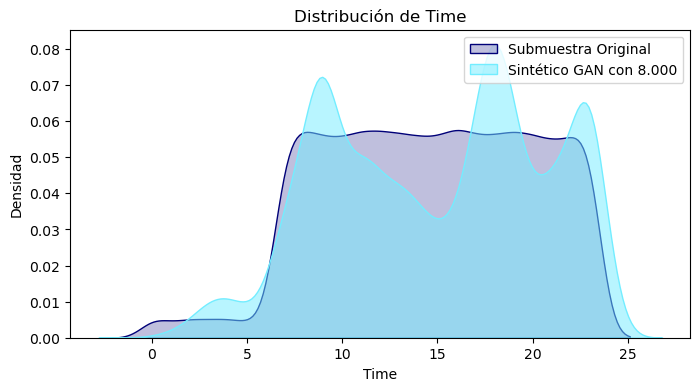

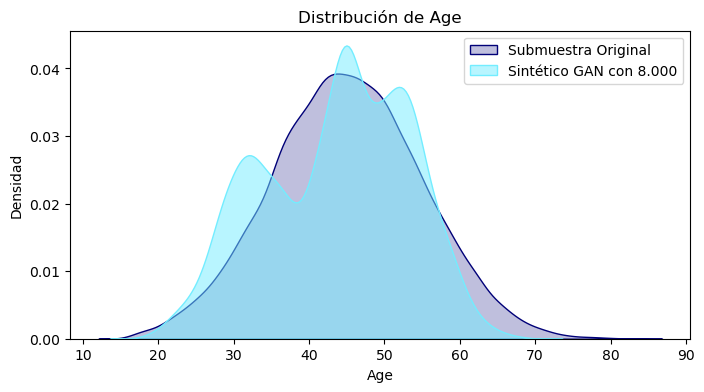

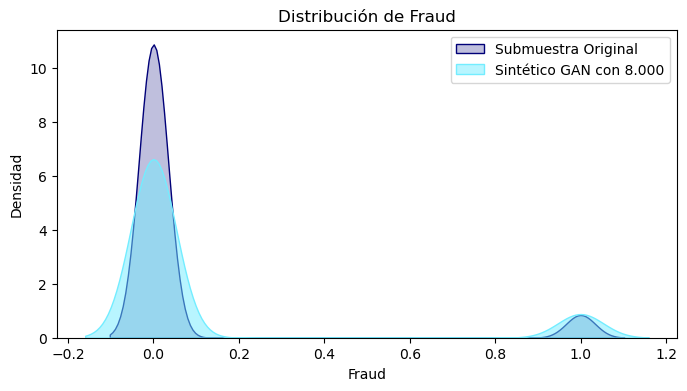

In [49]:
num_cols_sub = sint_GAN_sub_8k.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols_sub:
    plt.figure(figsize=(8,4))
    sns.kdeplot(sint_GAN_sub[col], label='Submuestra Original', fill=True, color='#000078')
    sns.kdeplot(sint_GAN_sub_8k[col], label='Sintético GAN con 8.000', fill=True, alpha=0.5, color='#73EDFF')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()
    

In [50]:
#Preparación del original sin fecha
target_col = 'Fraud'

X = sint_GAN_sub.drop(columns=[target_col])
y = sint_GAN_sub[target_col]

X_train_real_red, X_test_real_red, y_train_real_red, y_test_real_red = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_red = X_train_real_red
y_train_red = y_train_real_red

X_test_red = X_test_real_red
y_test_red = y_test_real_red

#Submuestra + Sintético GAN con 8.000
X_GAN_red = sint_GAN_sub_8k.drop(columns=['Fraud'])
y_GAN_red = sint_GAN_sub_8k['Fraud']

X_train_GAN_red = pd.concat([X_train_red, X_GAN_red])
y_train_GAN_red = pd.concat([y_train_red, y_GAN_red])

In [51]:
#Creación y evaluación del modelo sobre el original reducido
pipeline_lgbm = Pipeline([
    ('prep', preprocessor), 
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
]) 
pipeline_lgbm.fit(X_train_real, y_train_real) 

y_pred_lgbm = pipeline_lgbm.predict(X_test_real)
y_proba_lgbm = pipeline_lgbm.predict_proba(X_test_real)[:, 1]

auc_lgbm = roc_auc_score(y_test_real, y_proba_lgbm)
recall_lgbm = recall_score(y_test_real, y_pred_lgbm)
f1_lgbm = f1_score(y_test_real, y_pred_lgbm)


[LightGBM] [Info] Number of positive: 5754, number of negative: 74227
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.180943 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 79981, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [52]:
#Creación y evaluación del modelo + sintético
pipeline_lgbm_red = Pipeline([
    ('prep', preprocessor), 
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
]) 
pipeline_lgbm_red.fit(X_train_red, y_train_red) 

y_pred_lgbm_red = pipeline_lgbm_red.predict(X_test_red)
y_proba_lgbm_red = pipeline_lgbm_red.predict_proba(X_test_red)[:, 1]

auc_lgbm_red = roc_auc_score(y_test_red, y_proba_lgbm_red)
recall_lgbm_red = recall_score(y_test_red, y_pred_lgbm_red)
f1_lgbm_red = f1_score(y_test_red, y_pred_lgbm_red)


[LightGBM] [Info] Number of positive: 1438, number of negative: 18557
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.299606 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 19995, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [53]:
#Comparación resultados
print("Light Gradient Boosting - Dataset Original Reducido")
print(f"AUC:      {auc_lgbm:.4f}")
print(f"Recall:   {recall_lgbm:.4f}")
print(f"F1-score: {f1_lgbm:.4f}")

print("\nLight Gradient Boosting - Dataset GAN 8k")
print(f"AUC:      {auc_lgbm_red:.4f}")
print(f"Recall:   {recall_lgbm_red:.4f}")
print(f"F1-score: {f1_lgbm_red:.4f}")


Light Gradient Boosting - Dataset Original Reducido
AUC:      0.9898
Recall:   0.9270
F1-score: 0.7268

Light Gradient Boosting - Dataset GAN 8k
AUC:      0.9851
Recall:   0.8417
F1-score: 0.7779


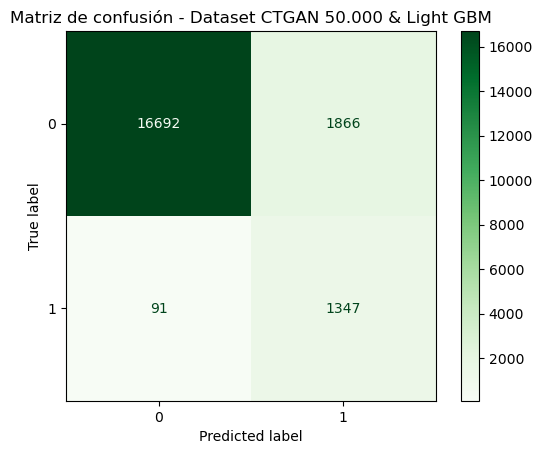

In [64]:
#Matriz confusion GAN_50k

cm_GAN_50k = confusion_matrix(y_test_ori, y_pred_lgbm_GAN_50k)
disp_GAN_50k_lgbm = ConfusionMatrixDisplay(confusion_matrix=cm_GAN_50k, display_labels=[0, 1])

disp_GAN_50k_lgbm.plot(cmap='Greens', values_format='d')
plt.title("Matriz de confusión - Dataset CTGAN 50.000 & Light GBM")
plt.show()

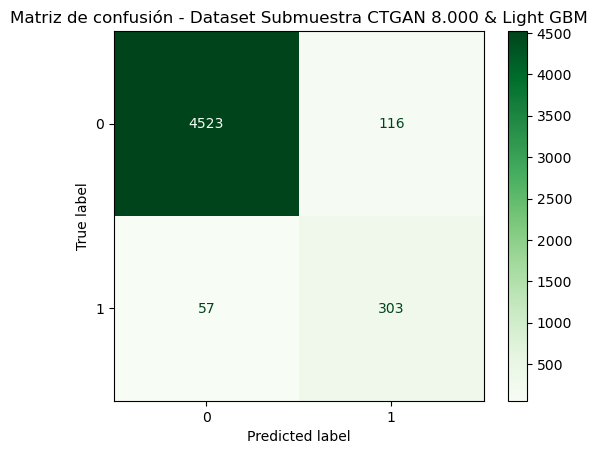

In [66]:
#Matriz confusion GAN submuestra

cm_GAN_sub_8k = confusion_matrix(y_test_red, y_pred_lgbm_red)
disp_GAN_sub_8k_lgbm = ConfusionMatrixDisplay(confusion_matrix=cm_GAN_sub_8k, display_labels=[0, 1])

disp_GAN_sub_8k_lgbm.plot(cmap='Greens', values_format='d')
plt.title("Matriz de confusión - Dataset Submuestra CTGAN 8.000 & Light GBM")
plt.show()

### 4. Comparación modelo Light Gradient Boosting sobre dataset original y sintético CTGAN

In [54]:
#Resultados previos
y_pred_lgbm_GAN_50k = pipeline_lgbm_GAN_50k.predict(X_test_ori)
y_proba_lgbm_GAN_50k = pipeline_lgbm_GAN_50k.predict_proba(X_test_ori)[:, 1]

auc_lgbm_GAN_50k = roc_auc_score(y_test_ori, y_proba_lgbm_GAN_50k)
recall_lgbm_GAN_50k = recall_score(y_test_ori, y_pred_lgbm_GAN_50k)
f1_lgbm_GAN_50k = f1_score(y_test_ori, y_pred_lgbm_GAN_50k)

print("\nLight Gradient Boosting - Dataset Original")
print(f"AUC:      {auc_lgbm_ori:.4f}")
print(f"Recall:   {recall_lgbm_ori:.4f}")
print(f"F1-score: {f1_lgbm_ori:.4f}")

print("\nLight Gradient Boosting - Dataset CTGAN 50k")
print(f"AUC:      {auc_lgbm_GAN_50k:.4f}")
print(f"Recall:   {recall_lgbm_GAN_50k:.4f}")
print(f"F1-score: {f1_lgbm_GAN_50k:.4f}")


Light Gradient Boosting - Dataset Original
AUC:      0.9898
Recall:   0.9270
F1-score: 0.7266

Light Gradient Boosting - Dataset CTGAN 50k
AUC:      0.9746
Recall:   0.9367
F1-score: 0.5792


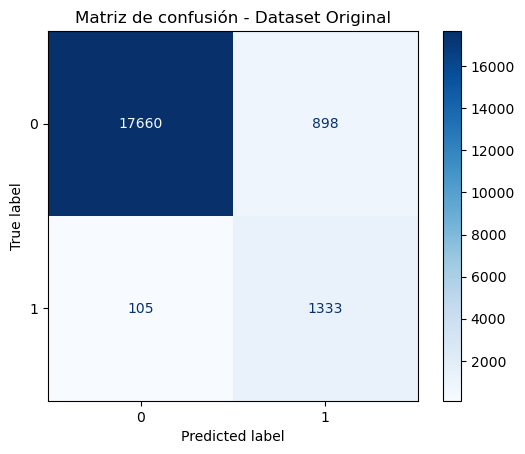

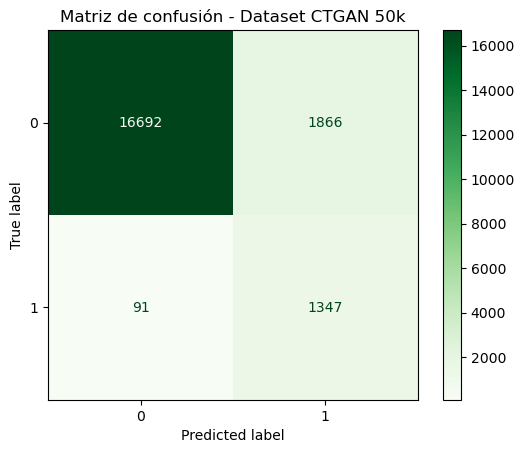

In [55]:
#Matriz de confusión

cm_ori = confusion_matrix(y_test_ori, y_pred_lgbm_ori)
disp_ori = ConfusionMatrixDisplay(confusion_matrix=cm_ori, display_labels=[0, 1])

cm_GAN = confusion_matrix(y_test_ori, y_pred_lgbm_GAN_50k)
disp_GAN = ConfusionMatrixDisplay(confusion_matrix=cm_GAN, display_labels=[0, 1])

disp_ori.plot(cmap='Blues', values_format='d')
plt.title("Matriz de confusión - Dataset Original")
plt.show()

disp_GAN.plot(cmap='Greens', values_format='d')
plt.title("Matriz de confusión - Dataset CTGAN 50k")
plt.show()


In [69]:
#Cálculo top 10 variables con dataset original
lgbm_model_ori = pipeline_lgbm_ori.named_steps['model']
X_test_t = pipeline_lgbm_ori.named_steps['prep'].transform(X_test_real)

# Convertir formato
if hasattr(X_test_t, "toarray"):
    X_test_dense_ori = X_test_t.toarray()
else:
    X_test_dense_ori = X_test_transformed

#Calcular valores
explainer_ori = shap.TreeExplainer(lgbm_model_ori)
shap_values_ori = explainer_ori.shap_values(X_test_dense_ori)

if isinstance(shap_values_ori, list):
    shap_values_class_ori = shap_values_ori[1]
else:
    shap_values_class_ori = shap_values_ori

#Nivel importancia
feature_names_ori = pipeline_lgbm_ori.named_steps['prep'].get_feature_names_out()
shap_importance_ori = np.abs(shap_values_class_ori).mean(axis=0)

shap_df_ori = pd.DataFrame({
    "feature": feature_names_ori,
    "shap_importance": shap_importance_ori
}).sort_values(by="shap_importance", ascending=False)

print("Top 10 variables modelo Light Gradient Boosting Dataset Original:")
print(shap_df_ori.head(10))


Top 10 variables modelo Light Gradient Boosting Dataset Original:
                                       feature  shap_importance
33        cat__Shipping Address_United Kingdom         1.990128
28  cat__Country of Transaction_United Kingdom         1.482756
38    cat__Country of Residence_United Kingdom         1.376864
0                                    num__Time         0.767395
6                 cat__Type of Card_MasterCard         0.297318
1                                     num__Age         0.295843
9                          cat__Entry Mode_PIN         0.242248
39                               cat__Gender_F         0.240418
14                cat__Merchant Group_Children         0.216184
34             cat__Country of Residence_China         0.202626


In [71]:
#Cálculo top 10 variables con dataset original + sintético CTGAN
lgbm_model_GAN = pipeline_lgbm_GAN_50k.named_steps['model']
X_test_t = pipeline_lgbm_GAN_50k.named_steps['prep'].transform(X_test_real)

# Convertir formato
if hasattr(X_test_t, "toarray"):
    X_test_dense_GAN = X_test_t.toarray()
else:
    X_test_dense_GAN = X_test_transformed

#Calcular valores
explainer_GAN = shap.TreeExplainer(lgbm_model_GAN)
shap_values_GAN = explainer_GAN.shap_values(X_test_dense_GAN)

if isinstance(shap_values_GAN, list):
    shap_values_class_GAN = shap_values_GAN[1]
else:
    shap_values_class_GAN = shap_values_GAN

#Nivel importancia
feature_names_GAN = pipeline_lgbm_GAN_50k.named_steps['prep'].get_feature_names_out()
shap_importance_GAN = np.abs(shap_values_class_GAN).mean(axis=0)

shap_df_GAN = pd.DataFrame({
    "feature": feature_names_GAN,
    "shap_importance": shap_importance_GAN
}).sort_values(by="shap_importance", ascending=False)

print("Top 10 variables modelo Light Gradient Boosting Dataset CTGAN 50k:")
print(shap_df_GAN.head(10))


Top 10 variables modelo Light Gradient Boosting Dataset CTGAN 50k:
                                       feature  shap_importance
33        cat__Shipping Address_United Kingdom         1.585452
28  cat__Country of Transaction_United Kingdom         0.730223
0                                    num__Time         0.380308
9                          cat__Entry Mode_PIN         0.351678
1                                     num__Age         0.156703
38    cat__Country of Residence_United Kingdom         0.150396
11                cat__Type of Transaction_ATM         0.123497
6                 cat__Type of Card_MasterCard         0.099876
8                          cat__Entry Mode_CVC         0.087480
14                cat__Merchant Group_Children         0.082692


In [72]:
#Correlación entre modelos
corr = np.corrcoef(shap_importance_ori, shap_importance_GAN)[0,1]
print(f"Correlación entre SHAP Dataset Original vs Dataset CTGAN 50k: {corr:.3f}")

Correlación entre SHAP Dataset Original vs Dataset CTGAN 50k: 0.869



Feature: num__Time
Modelo Dataset Original


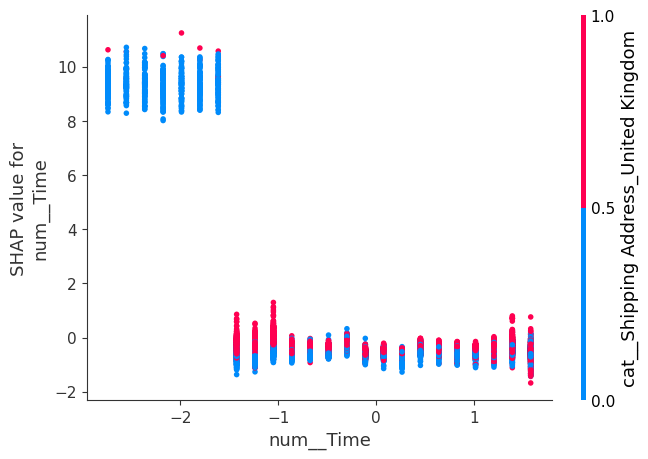

Dataset CTGAN 50k


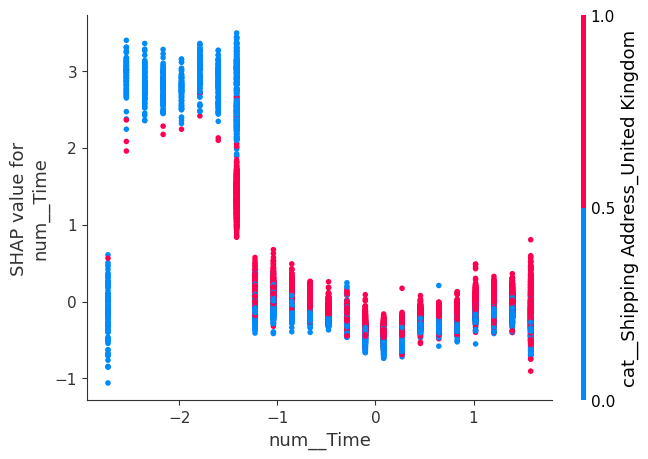


Feature: cat__Gender_F
Modelo Dataset Original


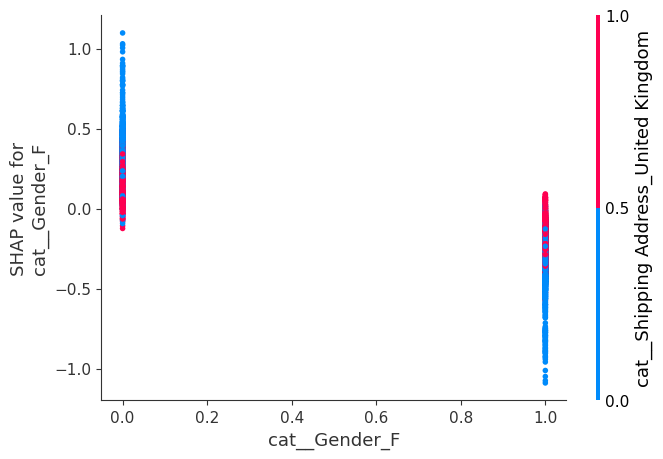

Dataset CTGAN 50k


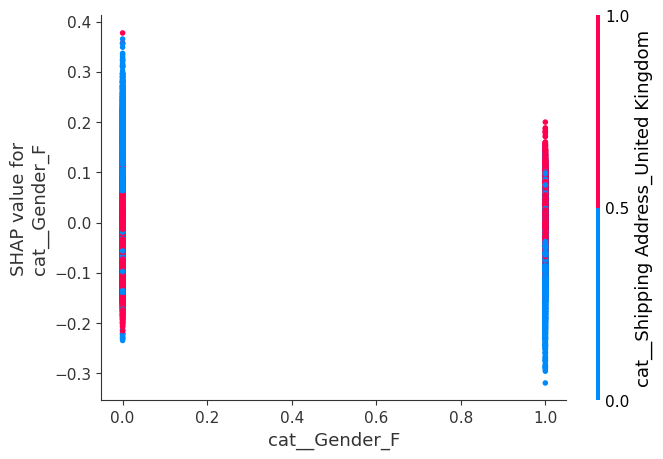


Feature: cat__Shipping Address_United Kingdom
Modelo Dataset Original


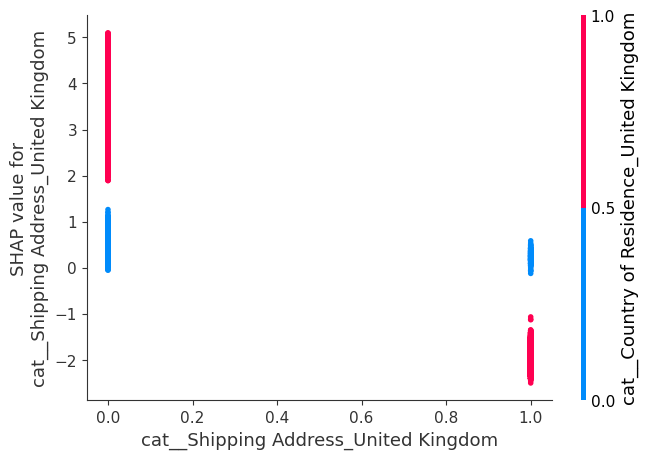

Dataset CTGAN 50k


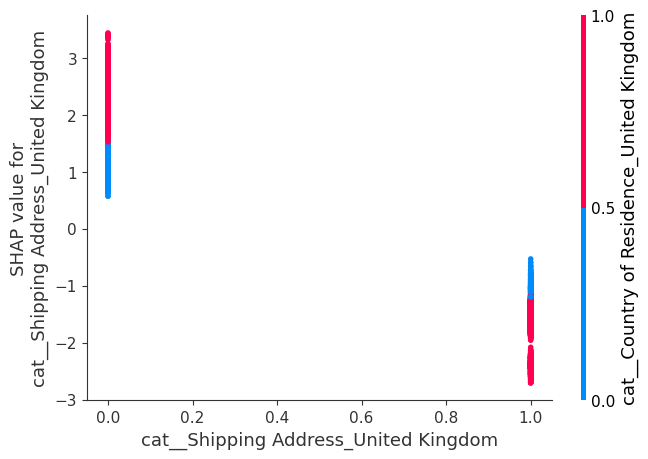

In [73]:
#Tendencia para variables destacadas

features_manual = [
    "num__Time",
    "cat__Gender_F",
    "cat__Shipping Address_United Kingdom"
]

for feat in features_manual:
    print("\n==============================")
    print(f"Feature: {feat}")
    print("==============================")

    idx = list(feature_names_ori).index(feat)

    print("Modelo Dataset Original")
    shap.dependence_plot(
        idx,
        shap_values_class_ori,
        X_test_dense_ori,
        feature_names=feature_names_ori,
        show=True
    )

    print("Dataset CTGAN 50k")
    shap.dependence_plot(
        idx,
        shap_values_class_GAN,
        X_test_dense_GAN,
        feature_names=feature_names_GAN,
        show=True
    )


